In [2]:
import numpy as np ; import matplotlib.pyplot as plt

def load_variables_to_dict(file_path):
    variables_dict = {}
    with open(file_path, 'r') as file:
        lines = file.readlines()
    for line in lines:
        if line.startswith('Variable'):
            parts = line.split(':')
            if len(parts) > 1:
                variable_info = parts[1].split('def =')
                if len(variable_info) > 1:
                    var_name = variable_info[0].split()[0].strip()
                    numerical_values = variable_info[1].split()
                    for value in numerical_values:
                        try:
                            num_value = float(value)
                            variables_dict[var_name.split(',')[0]] = num_value
                            break
                        except ValueError:
                            continue
    return variables_dict


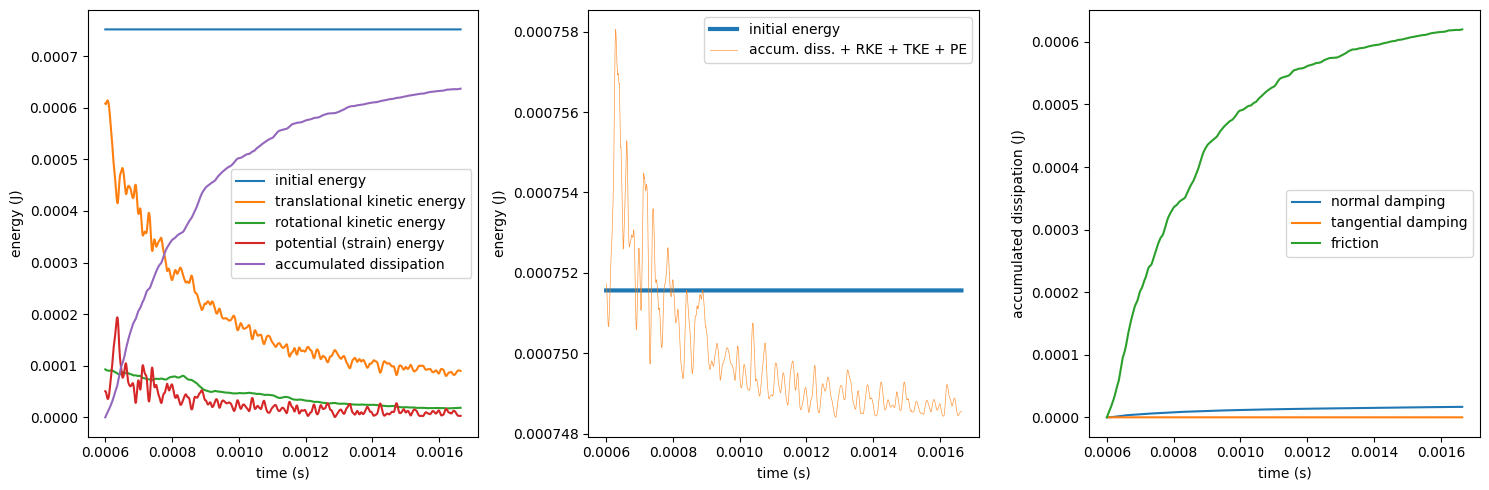

In [621]:

data = np.loadtxt('energy.dat', skiprows=1)
parameters = load_variables_to_dict('info')

time = data[:, 0].astype(int)*parameters['timeStep']
kin_eng = data[:, 1]
rotkin_eng = data[:, 2]
pot_eng = data[:, 3]
diss1 = data[:, 4]*parameters['avewindow']
diss2 = data[:, 5]*parameters['avewindow']
diss3 = data[:, 6]*parameters['avewindow']
meanTemp = data[:, 7]*parameters['avewindow']/64
total_diss = diss1+diss2+diss3
E0 = np.array([kin_eng[0] + pot_eng[0] + rotkin_eng[0]] * len(time))

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].set_xlabel('time (s)')
axs[0].set_ylabel('energy (J)')
axs[0].plot(time, E0, label='initial energy')
axs[0].plot(time, kin_eng, label='translational kinetic energy')
axs[0].plot(time, rotkin_eng, label='rotational kinetic energy')
axs[0].plot(time, pot_eng, label='potential (strain) energy')
axs[0].plot(time, np.cumsum(total_diss), label='accumulated dissipation')
axs[0].legend()
axs[1].set_xlabel('time (s)')
axs[1].set_ylabel('energy (J)')
axs[1].plot(time, E0, lw=3, label='initial energy')
axs[1].plot(time, np.cumsum(total_diss) + kin_eng + rotkin_eng + pot_eng, 
    alpha=0.8, lw=0.5, label='accum. diss. + RKE + TKE + PE')
axs[1].legend()
#axs[1].set_ylim(0,E0[0]*1.2)
axs[2].set_xlabel('time (s)')
axs[2].set_ylabel('accumulated dissipation (J)')
axs[2].plot(time, np.cumsum(diss1), label='normal damping')
axs[2].plot(time, np.cumsum(diss2), label='tangential damping')
axs[2].plot(time, np.cumsum(diss3), label='friction')
#axs[2].set_yscale('log')
axs[2].legend()
plt.tight_layout()


-5.37946e-09


Text(0, 0.5, 'dissipation increment')

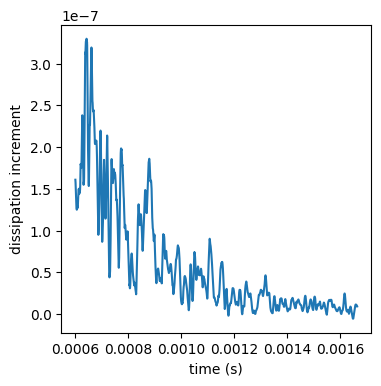

In [622]:
plt.figure(figsize=(4,4))
plt.plot(time, diss3)
print(np.min(diss3))
plt.xlabel('time (s)'); plt.ylabel('dissipation increment')

Text(0, 0.5, 'mean temperature (deg K)')

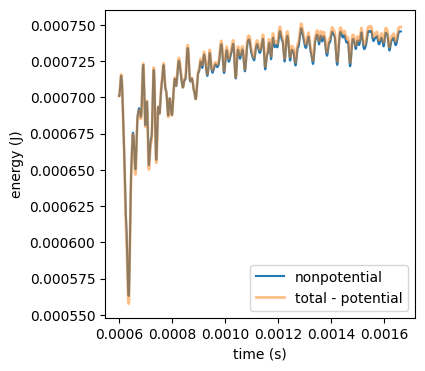

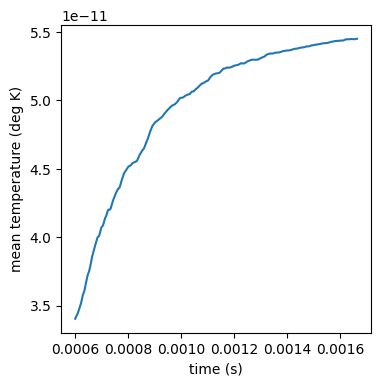

In [623]:
plt.figure(figsize=(4,4))
plt.plot(time, np.cumsum(total_diss) + kin_eng + rotkin_eng, label='nonpotential')
plt.plot(time, E0 - pot_eng, alpha=0.5, lw=2, label='total - potential')
plt.xlabel('time (s)'); plt.ylabel('energy (J)')
plt.legend()

plt.figure(figsize=(4,4))
plt.plot(time, meanTemp)
plt.xlabel('time (s)'); plt.ylabel('mean temperature (deg K)')